Color Image Shape: (5400, 4320, 3)
Grayscale Image Shape: (5400, 4320)


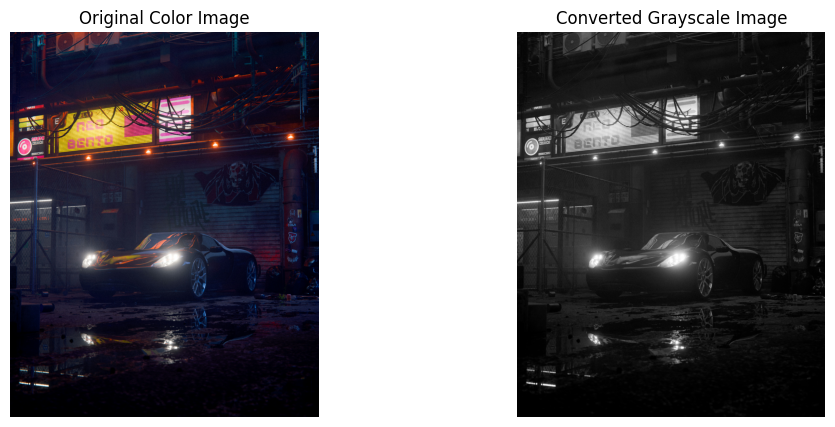

In [ ]:
# LAB 4 - Spatial & Frequency Filtering
# Part 1: Load Image (Color → Grayscale Conversion)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from ipywidgets import interact, IntSlider, FloatSlider
import warnings
warnings.filterwarnings("ignore")

# Read image in COLOR
img_color = cv2.imread('/content/Lab4.jpg')

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Convert grayscale to float
img_gray = img_gray.astype(np.float32)

print("Color Image Shape:", img_rgb.shape)
print("Grayscale Image Shape:", img_gray.shape)

# Display images
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title("Converted Grayscale Image")
plt.axis('off')

plt.show()

In [ ]:
# PART 2A - Interactive Mean Filter

def mean_filter(kernel_size):

    # Apply mean filter
    blurred = cv2.blur(img_gray, (kernel_size, kernel_size))

    # Show images
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original Grayscale")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(blurred, cmap='gray')
    plt.title(f"Mean Filter (Kernel={kernel_size}x{kernel_size})")
    plt.axis('off')

    plt.show()

    # Histogram
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(img_gray.ravel(), bins=256)
    plt.title("Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(blurred.ravel(), bins=256)
    plt.title("Blurred Histogram")

    plt.show()

    # MSE
    mse = np.mean((img_gray - blurred)**2)
    print("MSE:", mse)


interact(mean_filter, kernel_size=IntSlider(min=1, max=21, step=2, value=3))

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), Output()), _dom_cl…

<function __main__.mean_filter(kernel_size)>

In [ ]:
# PART 2B - Interactive Gaussian Filter

def gaussian_filter(kernel_size, sigma):

    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), sigma)

    # Show images
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original Grayscale")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(blurred, cmap='gray')
    plt.title(f"Gaussian (Kernel={kernel_size}, Sigma={sigma})")
    plt.axis('off')

    plt.show()

    # Histogram
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(img_gray.ravel(), bins=256)
    plt.title("Original Histogram")

    plt.subplot(1,2,2)
    plt.hist(blurred.ravel(), bins=256)
    plt.title("Gaussian Histogram")

    plt.show()

    mse = np.mean((img_gray - blurred)**2)
    print("MSE:", mse)


interact(
    gaussian_filter,
    kernel_size=IntSlider(min=1, max=21, step=2, value=3),
    sigma=FloatSlider(min=0.1, max=10, step=0.5, value=1)
)

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), FloatSlider(value=…

<function __main__.gaussian_filter(kernel_size, sigma)>

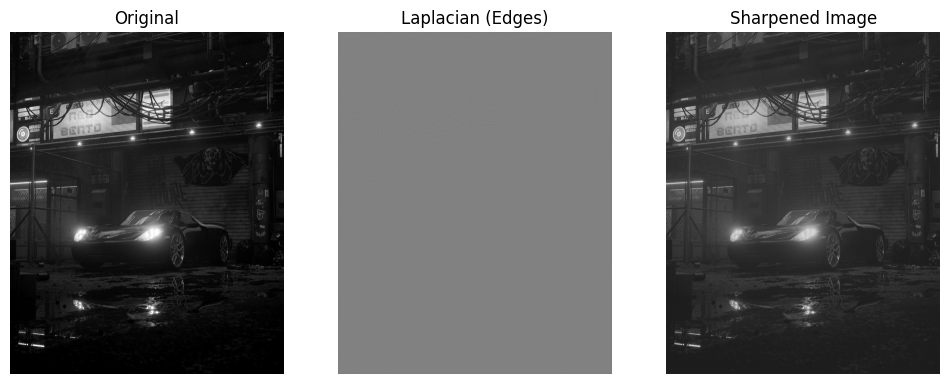

MSE: 29.010706


In [ ]:
# PART 3A - Laplacian Sharpening

def laplacian_sharpen():

    laplacian = cv2.Laplacian(img_gray, cv2.CV_32F)

    sharpened = img_gray - laplacian

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(laplacian, cmap='gray')
    plt.title("Laplacian (Edges)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Sharpened Image")
    plt.axis('off')

    plt.show()

    mse = np.mean((img_gray - sharpened)**2)
    print("MSE:", mse)


laplacian_sharpen()

In [ ]:
# PART 3B - Unsharp Masking

def unsharp_mask(kernel_size):

    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), 0)

    mask = img_gray - blurred

    sharpened = img_gray + mask

    plt.figure(figsize=(12,5))

    plt.subplot(1,3,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (Edges)")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(sharpened, cmap='gray')
    plt.title("Unsharp Result")
    plt.axis('off')

    plt.show()


interact(unsharp_mask, kernel_size=IntSlider(min=1, max=21, step=2, value=3))

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), Output()), _dom_cl…

<function __main__.unsharp_mask(kernel_size)>

In [ ]:
# PART 3C - High Boost Filtering

def high_boost(kernel_size, k):

    blurred = cv2.GaussianBlur(img_gray, (kernel_size, kernel_size), 0)

    mask = img_gray - blurred

    highboost = img_gray + k * mask

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(highboost, cmap='gray')
    plt.title(f"High Boost (k={k})")
    plt.axis('off')

    plt.show()

    mse = np.mean((img_gray - highboost)**2)
    print("MSE:", mse)


interact(
    high_boost,
    kernel_size=IntSlider(min=1, max=21, step=2, value=3),
    k=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0)
)

interactive(children=(IntSlider(value=3, description='kernel_size', max=21, min=1, step=2), FloatSlider(value=…

<function __main__.high_boost(kernel_size, k)>

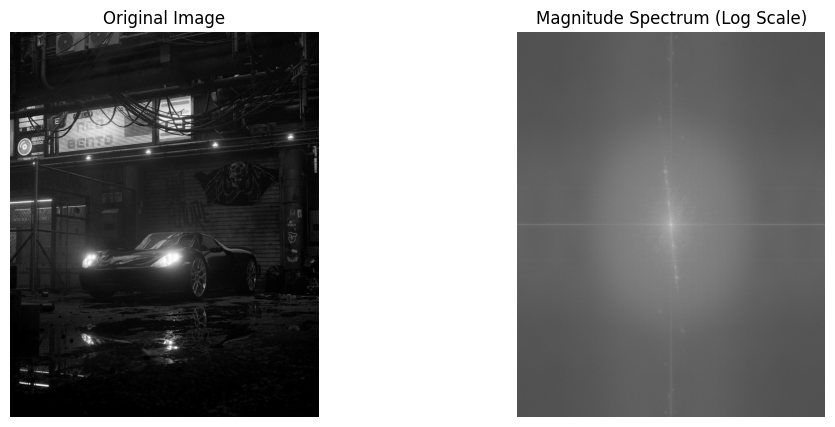

In [ ]:
# PART 4A - Fourier Transform

f = np.fft.fft2(img_gray)

# Shift center
fshift = np.fft.fftshift(f)

# Magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum (Log Scale)")
plt.axis('off')

plt.show()

In [ ]:
# PART 4B - Ideal Low Pass Filter

def ideal_low_pass(radius):

    rows, cols = img_gray.shape
    crow, ccol = rows//2, cols//2

    mask = np.zeros((rows, cols), np.uint8)

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= radius:
                mask[i,j] = 1

    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)

    fshift_filtered = fshift * mask

    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("Low Pass Mask")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"Low Pass Output (r={radius})")
    plt.axis('off')

    plt.show()


interact(ideal_low_pass, radius=IntSlider(min=10, max=200, step=10, value=50))

interactive(children=(IntSlider(value=50, description='radius', max=200, min=10, step=10), Output()), _dom_cla…

<function __main__.ideal_low_pass(radius)>

In [ ]:
# PART 4C - Ideal High Pass Filter

def ideal_high_pass(radius):

    rows, cols = img_gray.shape
    crow, ccol = rows//2, cols//2

    mask = np.ones((rows, cols), np.uint8)

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= radius:
                mask[i,j] = 0

    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)

    fshift_filtered = fshift * mask

    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(mask, cmap='gray')
    plt.title("High Pass Mask")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(img_back, cmap='gray')
    plt.title(f"High Pass Output (r={radius})")
    plt.axis('off')

    plt.show()


interact(ideal_high_pass, radius=IntSlider(min=10, max=200, step=10, value=50))

interactive(children=(IntSlider(value=50, description='radius', max=200, min=10, step=10), Output()), _dom_cla…

<function __main__.ideal_high_pass(radius)>